#Analisis Clustering pada Dataset Sleep Health and Lifestyle

Pada notebook ini saya melakukan analisis clustering menggunakan dataset Sleep Health and Lifestyle. Dataset ini berisi informasi mengenai kondisi kesehatan dan gaya hidup individu, seperti durasi tidur, tingkat stres, detak jantung, dan aktivitas harian.

Tujuan dari analisis ini adalah untuk mengelompokkan individu ke dalam beberapa kelompok berdasarkan kesamaan karakteristik yang dimiliki. Dengan melakukan clustering, saya dapat menemukan pola tersembunyi dalam data tanpa menggunakan label atau target tertentu.

Metode yang digunakan dalam analisis ini adalah K-Means Clustering, yaitu salah satu algoritma unsupervised learning yang digunakan untuk membagi data ke dalam beberapa cluster berdasarkan kemiripan.

#Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Pada bagian ini saya mengimpor library yang dibutuhkan seperti pandas untuk manipulasi data, matplotlib dan seaborn untuk visualisasi, serta sklearn untuk preprocessing dan clustering.

#Load Dataset

In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

print("5 Data Teratas:")
display(df.head())

print("Ukuran Dataset:")
print(df.shape)

5 Data Teratas:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


Ukuran Dataset:
(374, 13)


Membaca dataset menggunakan pandas dan menampilkan beberapa data awal.

Hasil:

Dataset memiliki 374 baris dan 13 kolom. Dari data awal terlihat atribut seperti Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, dan lain-lain. Nilai Sleep Duration berada di kisaran 5.9–6.2 jam dan Stress Level sekitar 6–8, menunjukkan adanya variasi antar individu.

#Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


Digunakan untuk melihat tipe data dan struktur dataset.

Hasil:

Sebagian besar kolom memiliki 374 data lengkap, namun kolom Sleep Disorder hanya memiliki 155 data, sehingga terdapat missing value. Dataset terdiri dari data numerik dan kategorik, di mana data numerik digunakan untuk clustering.

#Cek Missing Value

In [ ]:
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


Digunakan untuk mengecek apakah terdapat data kosong (missing value) pada setiap kolom dataset sebelum dilakukan proses clustering.

Hasil:

Berdasarkan output, seluruh kolom memiliki nilai 0 missing value, seperti Person ID, Gender, Age, Occupation, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, BMI Category, Blood Pressure, Heart Rate, dan Daily Steps.

Namun, kolom Sleep Disorder memiliki 219 data kosong. Namun karena kolom ini tidak digunakan dalam proses clustering, maka missing value tersebut tidak memengaruhi analisis dan tidak memerlukan penanganan khusus.


# Pemilihan Fitur

In [ ]:
features = [
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Age'
]

data = df[features]
print(data.head())

   Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level  \
0             6.1                 6                       42             6   
1             6.2                 6                       60             8   
2             6.2                 6                       60             8   
3             5.9                 4                       30             8   
4             5.9                 4                       30             8   

   Heart Rate  Daily Steps  Age  
0          77         4200   27  
1          75        10000   28  
2          75        10000   28  
3          85         3000   28  
4          85         3000   28  


Memilih beberapa fitur numerik yang relevan untuk clustering. Fitur yang dipilih adalah Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, Heart Rate, Daily Steps, dan Age.

Hasil:

Dari tujuh data terlihat:

*   Durasi tidur berada di kisaran 5.9 – 6.2 jam
*   Quality of Sleep berada pada nilai 4 – 6
*   Physical Activity Level berada di kisaran 30 – 60
*   Stress level berada di kisaran 6 – 8
*   Heart rate berada di kisaran 75 – 85 bpm
*   Daily steps berada di kisaran 3000 – 10000 langkah
*   Usia berada di kisaran 27 – 28 tahun

Ketujuh fitur tersebut cukup representatif untuk menggambarkan kondisi kesehatan, kualitas tidur, aktivitas harian, dan karakteristik individu.

#Normalisasi Data

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_scaled, columns=features)

print(data_scaled.head())

   Sleep Duration  Stress Level  Heart Rate  Daily Steps
0        0.111111           0.6    0.571429     0.171429
1        0.148148           1.0    0.476190     1.000000
2        0.148148           1.0    0.476190     1.000000
3        0.037037           1.0    0.952381     0.000000
4        0.037037           1.0    0.952381     0.000000


Normalisasi dilakukan agar semua fitur berada pada skala yang sama.

Hasil:

Setelah menggunakan MinMaxScaler, seluruh nilai berubah ke rentang 0 sampai 1.

Contohnya:
*   Sleep Duration = 0.111111
*   Stress Level = 0.6
*   Heart Rate = 0.571429
*   Daily Steps = 0.171429

Hal ini menunjukkan bahwa tidak ada fitur dengan skala terlalu besar yang mendominasi proses clustering.




#Menentukan Jumlah Cluster (Elbow Method)

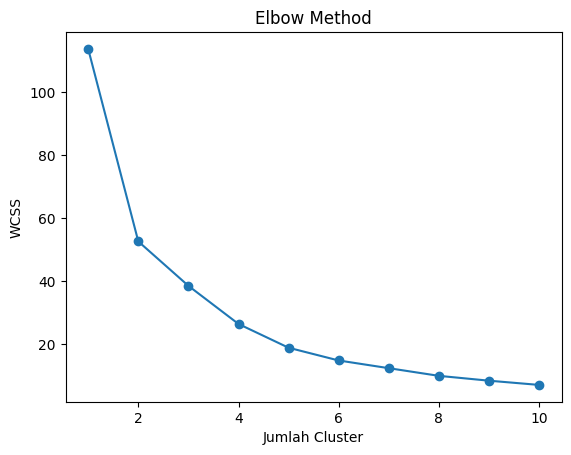

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.show()

Digunakan untuk menentukan jumlah cluster optimal berdasarkan nilai WCSS.

Hasil:

Grafik menunjukkan penurunan WCSS yang sangat tajam dari cluster 1 ke 3, lalu mulai melandai setelahnya.

Titik siku (elbow) terlihat berada di sekitar k = 3, sehingga jumlah cluster optimal yang dipilih adalah 3 cluster.

#Silhouette Score Beberapa Cluster

In [ ]:
for k in range(2,7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print("k =", k, "score =", score)

k = 2 score = 0.5118111198345107
k = 3 score = 0.4591697549421126
k = 4 score = 0.5211053293564928
k = 5 score = 0.5638539422501988
k = 6 score = 0.5845912586642632


Digunakan untuk mengevaluasi kualitas cluster pada beberapa nilai K.

Hasil:

Nilai Silhouette tertinggi terdapat pada k = 6, sehingga secara evaluasi matematis jumlah cluster terbaik adalah 6 cluster.Namun, apabila mempertimbangkan hasil Elbow Method dan kemudahan interpretasi, jumlah 3 cluster masih dapat digunakan karena lebih sederhana dan tetap memiliki kualitas cluster yang cukup baik.

#K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)

df['Cluster'] = clusters

print(df[['Sleep Duration', 'Stress Level', 'Cluster']].head())

   Sleep Duration  Stress Level  Cluster
0             6.1             6        2
1             6.2             8        2
2             6.2             8        2
3             5.9             8        2
4             5.9             8        2


Menerapkan algoritma K-Means untuk membagi data ke dalam beberapa cluster.

Hasil:

Dataset berhasil dibagi menjadi 3 cluster, yaitu cluster 0, 1, dan 2. Dari lima data pertama, seluruh data awal masuk ke cluster 2, yang berarti lima individu pertama memiliki karakteristik yang mirip.

#Visualisasi Cluster

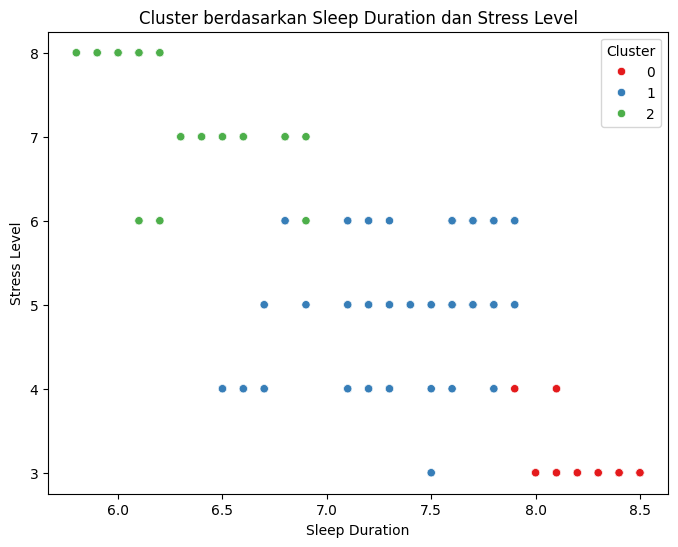

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Sleep Duration'],
    y=df['Stress Level'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Cluster berdasarkan Sleep Duration dan Stress Level")
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.show()

Digunakan untuk melihat persebaran cluster berdasarkan Sleep Duration dan Stress Level.

Hasil:

Terlihat tiga kelompok data yang cukup jelas:
*  Cluster 0 (merah) cenderung memiliki durasi tidur tinggi (8+ jam) dan stress rendah (3–4)
*   Cluster 1 (biru) memiliki durasi tidur sedang (6.5–7.8 jam) dan stress sedang (4–6)
*  Cluster 2 (hijau) memiliki durasi tidur rendah (5.8–6.9 jam) dan stress tinggi (6–8)

Hal ini menunjukkan adanya hubungan bahwa semakin rendah durasi tidur, tingkat stres cenderung lebih tinggi.



#Analisis Hasil Cluster

In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

         Sleep Duration  Stress Level  Heart Rate  Daily Steps
Cluster                                                       
0              8.238889      3.041667   67.180556  6058.333333
1              7.320904      4.830508   68.768362  7191.525424
2              6.227200      7.520000   73.864000  6723.200000


Digunakan untuk melihat karakteristik setiap cluster.

Hasil:

*   Cluster 0 = tidur cukup, stres rendah, detak jantung rendah
*   Cluster 1 = tidur sedang, aktivitas tertinggi
*   Cluster 2 = tidur rendah, stres tertinggi, detak jantung tertinggi



#Visualisasi Tambahan (Heart Rate vs Steps)

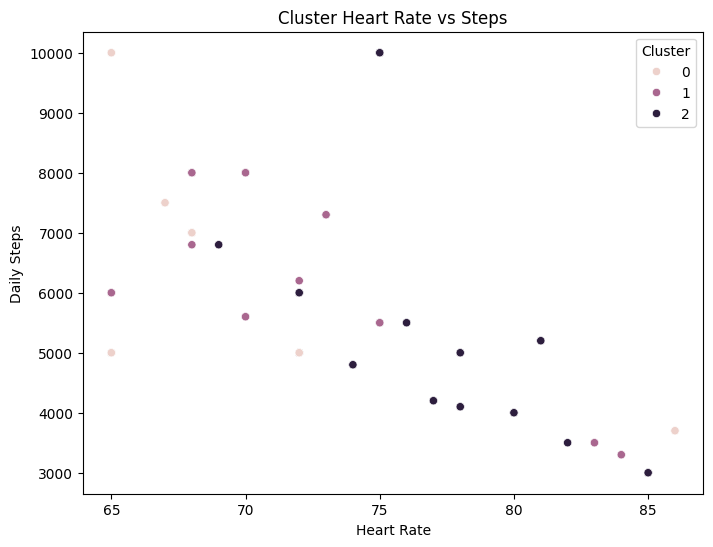

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Heart Rate'], y=df['Daily Steps'], hue=df['Cluster'])
plt.title("Cluster Heart Rate vs Steps")
plt.show()

Digunakan untuk melihat hubungan detak jantung dengan jumlah langkah harian.

Hasil:
*   Cluster 1 memiliki langkah harian tertinggi (hingga 10.000 langkah)
*   Cluster 2 memiliki heart rate lebih tinggi (75–85 bpm)
*   Cluster 0 cenderung memiliki heart rate rendah dan aktivitas sedang

Ini menunjukkan individu aktif cenderung memiliki pola cluster berbeda.


#Boxplot per Cluster

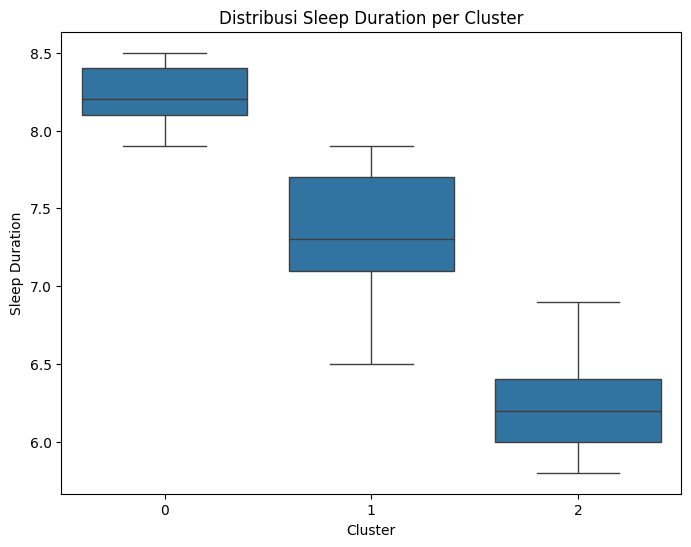

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Cluster', y='Sleep Duration', data=df)
plt.title("Distribusi Sleep Duration per Cluster")
plt.show()

Digunakan untuk melihat distribusi durasi tidur dalam setiap cluster.

Hasil:
*   Cluster 0 memiliki durasi tidur tertinggi (sekitar 8–8.5 jam)
*  Cluster 1 memiliki durasi tidur sedang (6.5–7.9 jam)
*  Cluster 2 memiliki durasi tidur terendah (5.8–6.9 jam)


#Visualisasi Perbandingan Cluster

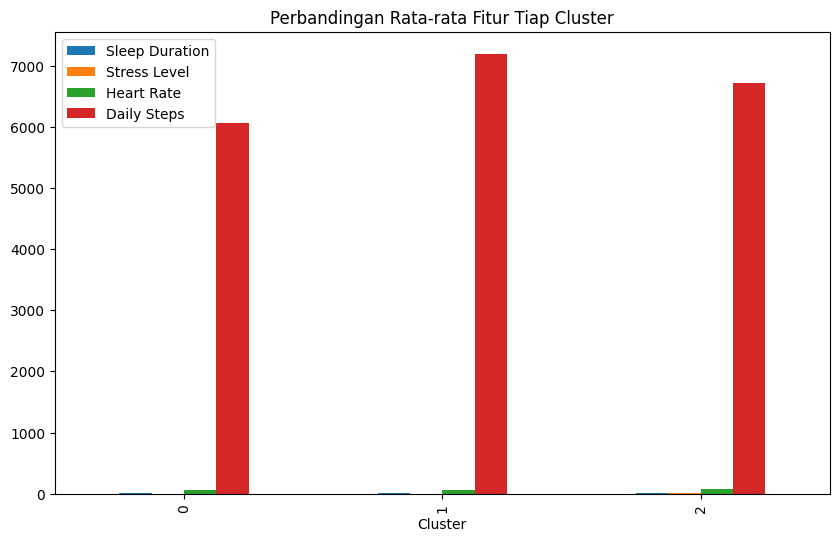

In [ ]:
cluster_mean.plot(kind='bar', figsize=(10,6))
plt.title("Perbandingan Rata-rata Fitur Tiap Cluster")
plt.show()

Digunakan untuk membandingkan rata-rata seluruh fitur antar cluster.

Hasil:

Perbedaan paling terlihat terdapat pada
Sleep Duration, Stress Level, dan Daily Steps.

Cluster 0 unggul pada durasi tidur, Cluster 1 unggul pada aktivitas, dan Cluster 2 memiliki stres tertinggi.

#Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(data_scaled, df['Cluster'])
print(score)

0.4591697549421126


Digunakan untuk mengevaluasi kualitas clustering.

Hasil:

Nilai Silhouette Score yang diperoleh adalah 0.4591697549421126. Nilai ini menunjukkan bahwa cluster terbentuk cukup baik, karena mendekati 0.5. Artinya antar cluster cukup terpisah dan anggota dalam cluster cukup mirip.

#PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

Digunakan untuk mereduksi dimensi data menjadi 2 dimensi.


#Visualisasi PCA

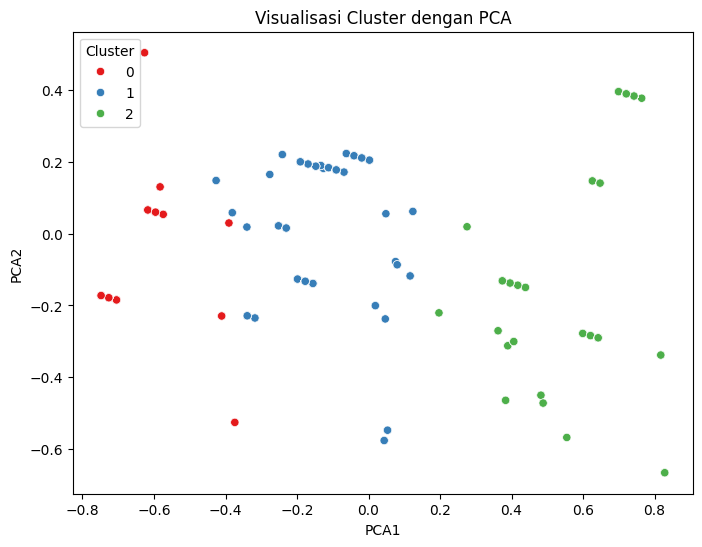

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['PCA1'],
    y=df['PCA2'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Visualisasi Cluster dengan PCA")
plt.show()

Visualisasi ini digunakan untuk melihat hasil clustering dalam bentuk 2 dimensi menggunakan PCA.

Hasil:
*   Cluster 2 (hijau) berada dominan di sisi kanan grafik
*   Cluster 0 (merah) berada di sisi kiri
*  Cluster 1 (biru) berada di tengah

Sebagian besar cluster sudah terpisah dengan cukup jelas, walaupun masih ada beberapa titik berdekatan. Ini menunjukkan bahwa model clustering bekerja cukup baik dalam memisahkan data.

#Kesimpulan

Pada proses ini saya melakukan clustering menggunakan K-Means untuk mengelompokkan individu berdasarkan pola tidur, stres, dan aktivitas.Data berhasil dibagi menjadi beberapa cluster dengan karakteristik berbeda. Clustering ini membantu memahami pola gaya hidup dan kondisi kesehatan individu secara lebih terstruktur.

## Google Colab tersedia di VS Code.
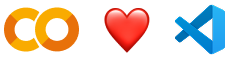

Coba <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">ekstensi Google Colab</a> yang baru untuk Visual Studio Code. Anda dapat mulai menjalankannya hanya dengan beberapa klik:

*  Di VS Code, buka tampilan <strong><em>Extensions</em></strong> dan telusuri 'Google Colab' untuk menginstalnya.
*  Buka pemilih kernel dengan membuat atau membuka file notebook berformat <code>.ipynb</code> di ruang kerja lokal Anda. Kemudian, jalankan sel atau klik tombol <strong><em>Select Kernel</em></strong> di kanan atas.
*  Klik <strong><em>Colab</em></strong>, lalu pilih runtime yang Anda inginkan, login dengan Akun Google Anda, dan selesai.

Lihat detail selengkapnya di <a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">blog pengumuman kami di sini</a>.

## 🎁 Paket Pro Gratis untuk Gemini &amp; Colab bagi Mahasiswa di Amerika Serikat 🎓

Dapatkan akses lebih luas ke model kami yang paling akurat, Gemini 3 Pro, untuk kebutuhan coding tingkat lanjut, riset kompleks, dan project inovatif. Model tersebut didukung oleh resource komputasi tinggi khusus Colab untuk data science dan machine learning.

Dapatkan penawaran gratis Gemini di <a href="https://gemini.google/students?utm_source=colab&amp;utm_medium=banner&amp;utm_campaign=students_xpa_us-colab-banner">gemini.google/students</a>.  
Dapatkan penawaran gratis Colab di <a href="https://colab.research.google.com/signup">colab.research.google.com/signup</a>.  
Persyaratan Berlaku.

## Akses model AI populer melalui Google-Colab-AI Tanpa Kunci API
Semua pengguna memiliki akses ke sebagian besar LLM populer melalui library Python <code>google-colab-ai</code>, dan pengguna berbayar memiliki akses ke pilihan model yang lebih banyak. Untuk mengetahui detail selengkapnya, lihat <a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb">memulai penggunaan google colab ai</a>.



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Pelajari Gemini API
Gemini API memberi Anda akses ke model Gemini yang dibuat oleh Google DeepMind. Sejak awal, model Gemini dirancang agar bersifat multimodal, sehingga Anda dapat melakukan analisis dengan lancar menggunakan teks, gambar, kode, dan audio.

**Ingin tahu cara memulai?**
*  Buka <a href="https://aistudio.google.com/">Google AI Studio</a> dan login dengan Akun Google Anda.
*  <a href="https://aistudio.google.com/app/apikey">Membuat kunci API</a>.
* Gunakan panduan memulai untuk <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb">Python</a>, atau panggil REST API menggunakan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.

**Temukan kemampuan canggih Gemini**
*  Bereksperimenlah dengan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb">output multimodal</a> Gemini, yang menggabungkan teks dan gambar secara iteratif.
*  Temukan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb">Multimodal Live API</a> &#40;demo tersedia <a href="https://aistudio.google.com/live">di sini</a>&#41;.
*  Pelajari cara <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb&quot;">menganalisis gambar dan mendeteksi item di foto Anda</a> menggunakan Gemini &#40;tersedia juga bonus <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb">versi 3D</a>&#41;.
*  Dapatkan manfaat dari <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb">model pemikiran Gemini</a>, yang mampu menyelesaikan berbagai tugas kompleks dengan pemikiran internalnya.
      
**Pelajari kasus penggunaan yang kompleks**
*  Gunakan <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb">kemampuan grounding Gemini</a> untuk membuat laporan tentang perusahaan berdasarkan informasi yang dapat ditemukan model di internet.
*  Ekstrak <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb">invoice dan data formulir dari PDF</a> dengan cara yang terstruktur.
*  Buat <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb">ilustrasi berdasarkan seluruh buku</a> menggunakan jendela konteks besar Gemini dan Imagen.

Untuk mempelajari lebih lanjut, lihat <a href="https://github.com/google-gemini/cookbook">cookbook Gemini</a> atau buka <a href="https://ai.google.dev/docs/">dokumentasi Gemini API</a>.


Colab kini memiliki fitur AI yang didukung oleh <a href="https://gemini.google.com">Gemini</a>. Video berikut memberikan informasi tentang cara menggunakan fitur ini, baik jika Anda baru mengenal Python, atau sudah berpengalaman.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  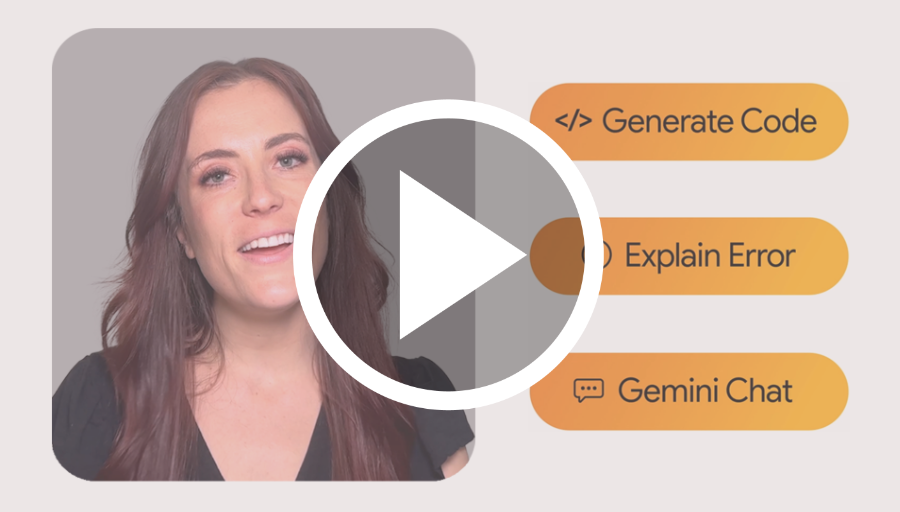
  </a>
</center>

<div class="markdown-google-sans">
  <h2>Apa itu Colab?</h2>
</div>

Colab, atau "Colaboratory", memungkinkan Anda menulis dan mengeksekusi Python di browser, dengan
- Tidak memerlukan konfigurasi
- Akses tanpa biaya ke GPU
- Berbagi dengan mudah

Baik Anda seorang <strong>siswa</strong>, <strong>data scientist</strong>, atau <strong>peneliti AI</strong>, Colab dapat memudahkan pekerjaan Anda. Tonton <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Pengantar Colab</a> atau <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Fitur Colab yang Mungkin Belum Anda Ketahui</a> untuk mempelajari lebih lanjut, atau cukup mulai di bawah ini.

<div class="markdown-google-sans">

## <strong>Memulai</strong>
</div>

Dokumen yang sedang Anda baca bukan halaman statis. Ini media interaktif bernama <strong>notebook Colab</strong> yang memungkinkan Anda menulis dan mengeksekusi kode.

Misalnya, berikut ini <strong>kode sel</strong> dengan skrip Python pendek yang mengomputasi sebuah nilai, menyimpannya dalam suatu variabel, dan mencetak hasilnya:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Untuk mengeksekusi kode dalam sel di atas, pilih kode tersebut dengan mengkliknya, kemudian tekan tombol putar di sebelah kiri kode atau gunakan pintasan keyboard "Command/Ctrl+Enter". Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Variabel yang Anda tentukan dalam sebuah sel nantinya dapat digunakan di sel lain:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Notebook Colab memungkinkan Anda menggabungkan <strong>kode yang dapat dijalankan</strong> dan <strong>rich text</strong> dalam satu dokumen, beserta <strong>gambar</strong>, <strong>HTML</strong>, <strong>LaTeX</strong>, dan lainnya. Saat Anda membuat notebook Colab Anda sendiri, notebook tersebut akan disimpan di akun Google Drive Anda. Anda dapat dengan mudah membagikan notebook Colab Anda dengan rekan kerja atau teman, sehingga memungkinkan mereka memberikan komentar di notebook Anda atau bahkan mengeditnya. Untuk mempelajari lebih lanjut, buka <a href="/notebooks/basic_features_overview.ipynb">Ringkasan Colab</a>. Untuk membuat notebook Colab baru, Anda dapat menggunakan menu File di atas, atau menggunakan link berikut: <a href="http://colab.research.google.com#create=true">buat notebook Colab baru</a>.

Notebook Colab adalah notebook Jupyter yang dihosting oleh Colab. Untuk mempelajari project Jupyter lebih lanjut, buka <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Ilmu data
</div>

Dengan Colab, Anda dapat memanfaatkan kecanggihan library Python yang populer untuk menganalisis dan memvisualisasikan data. Sel kode di bawah menggunakan <strong>numpy</strong> untuk menghasilkan beberapa data acak, dan menggunakan <strong>matplotlib</strong> untuk memvisualisasikannya. Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Anda dapat mengimpor data sendiri ke notebook Colab dari akun Google Drive Anda, termasuk dari spreadsheet, GitHub, dan berbagai sumber lainnya. Untuk mempelajari lebih lanjut pengimporan data dan bagaimana Colab dapat digunakan untuk ilmu data, lihat link di bawah pada bagian <a href="#working-with-data">Bekerja dengan Data</a>.

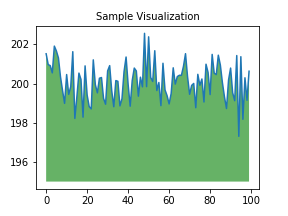

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Notebook Colab mengeksekusi kode di server cloud Google. Artinya, Anda dapat memanfaatkan kecanggihan hardware Google, termasuk <a href="#using-accelerated-hardware">GPU dan TPU</a>, terlepas dari kecanggihan komputer Anda. Yang Anda butuhkan hanyalah browser.

Misalnya, jika Anda harus menunggu kode <strong>pandas</strong> selesai dijalankan dan ingin mempercepat prosesnya, Anda dapat beralih ke Runtime GPU dan menggunakan library seperti <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> yang menyediakan akselerasi tanpa perubahan kode.

Untuk mempelajari lebih lanjut cara mempercepat pandas di Colab, lihat <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">panduan 10 menit</a> atau
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">demo analisis data pasar saham AS</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Dengan Colab, Anda dapat mengimpor set data gambar, melatih pengklasifikasi gambar di dalamnya, dan mengevaluasi model hanya dengan <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">beberapa baris kode</a>.

Colab digunakan secara luas di komunitas machine learning dengan berbagai penerapan meliputi:
- Memulai TensorFlow
- Mengembangkan dan melatih jaringan neural
- Bereksperimen dengan TPU
- Menyebarkan riset AI
- Membuat tutorial

Untuk melihat sampel notebook Colab yang menunjukkan penerapan machine learning, lihat <a href="#machine-learning-examples">contoh machine learning</a> di bawah.

<div class="markdown-google-sans">

## Referensi Lainnya

### Bekerja dengan Notebook di Colab

</div>

- [Ringkasan Colab](/notebooks/basic_features_overview.ipynb)
- [Panduan tentang Markdown](/notebooks/markdown_guide.ipynb)
- [Mengimpor library dan menginstal dependensi](/notebooks/snippets/importing_libraries.ipynb)
- [Menyimpan dan memuat notebook di GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulir interaktif](/notebooks/forms.ipynb)
- [Widget interaktif](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Bekerja dengan Data
</div>

- [Memuat data: Drive, Spreadsheet, dan Google Cloud Storage](/notebooks/io.ipynb)
- [Diagram: memvisualisasikan data](/notebooks/charts.ipynb)
- [Memulai BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

Berikut beberapa notebook yang terkait dengan Machine Learning, termasuk kursus Machine Learning online Google. Buka <a href="https://developers.google.com/machine-learning/crash-course/">situs kursus lengkap</a> untuk mengetahui info selengkapnya.
- [Pengantar Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Pengantar RAPIDS cuDF untuk mempercepat pandas](https://nvda.ws/rapids-cudf)
- [Mulai menggunakan mode akselerator cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Menggunakan Hardware yang Diakselerasi
</div>

- [Melatih CNN untuk mengklasifikasikan angka dari tulisan tangan pada set data MNIST menggunakan Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Melatih Vision Transformer &#40;ViT&#41; untuk klasifikasi gambar dengan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Klasifikasi teks dengan model bahasa transformer menggunakan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Contoh bagus

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Melatih model bahasa miniGPT dengan Stack AI JAX</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Fine-tuning LoRA/QLoRA untuk LLM menggunakan Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning &#40;PEFT&#41; Gemma dengan LoRA dan QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Memuat Checkpoint Hugging Face Transformer</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Kuantisasi Bilangan Bulat 8-bit di Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Pelatihan dan inferensi Float8 dengan model Transformer sederhana</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Melakukan pra-pelatihan Transformer dari awal dengan KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Convnet MNIST sederhana</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Klasifikasi gambar dari awal menggunakan Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Klasifikasi Gambar dengan KerasHub</a>
